# Import Libraries

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch

# Set plotting style

In [7]:
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

# Generate Synthetic "Customer" Data

In [8]:
# We create a dataset with 4 distinct clusters of varying densities, plus some random noise to test DBSCAN's outlier detection.
# Generate base clusters
X_core, y_true = make_blobs(n_samples=1500, centers=4, cluster_std=[1.0, 1.5, 0.5, 2.0], random_state=42)

# Generate uniform noise (outliers)
np.random.seed(42)
X_noise = np.random.uniform(low=-10, high=15, size=(100, 2))

In [9]:
# Combine and convert to DataFrame
X_raw = np.vstack([X_core, X_noise])
df = pd.DataFrame(X_raw, columns=['Annual_Spend', 'Purchase_Frequency'])

Dataset shape: (1600, 2)


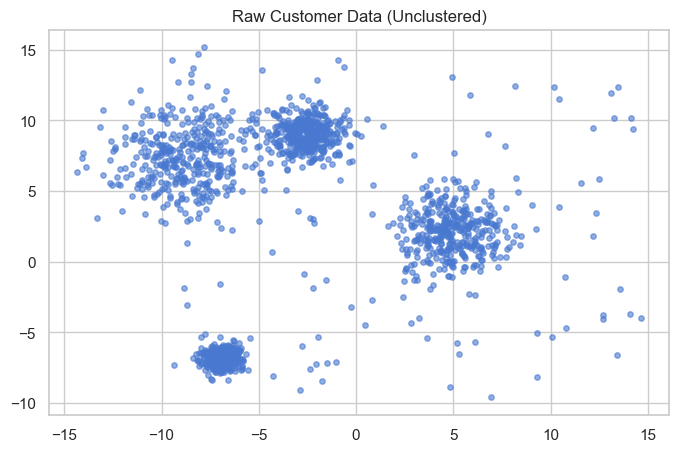

In [10]:
print(f"Dataset shape: {df.shape}")
plt.figure(figsize=(8, 5))
plt.scatter(df['Annual_Spend'], df['Purchase_Frequency'], alpha=0.6, s=15)
plt.title("Raw Customer Data (Unclustered)")
plt.show()

# Data Preprocessing

In [13]:
# Standardizing features is strictly required for distance-based clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [14]:
# We will use PCA for visualization purposes later
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means Clustering & Hyperparameter Tuning

In [15]:
# Using the Elbow Method and Silhouette Scores to find the optimal 'K'.
inertia = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans_temp.fit_predict(X_scaled)
    inertia.append(kmeans_temp.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans_labels))

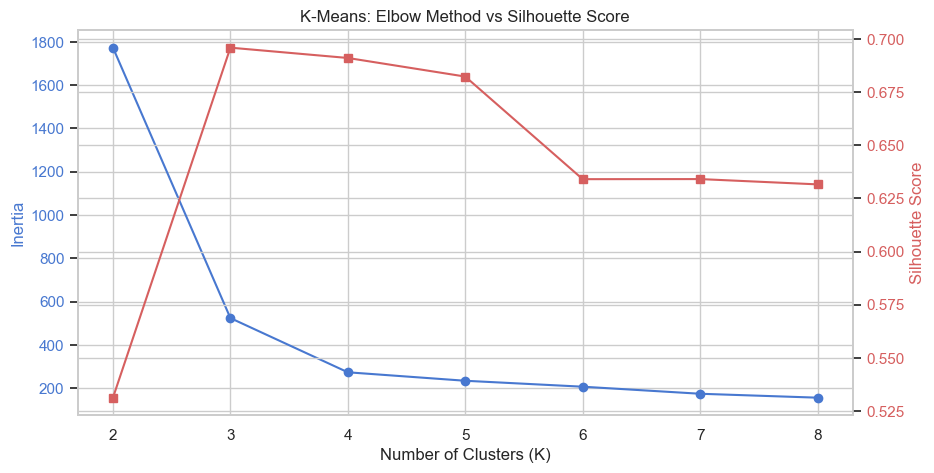

In [16]:
# Plot Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertia, marker='o', color='b', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, marker='s', color='r', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title("K-Means: Elbow Method vs Silhouette Score")
plt.show()

In [19]:
# Fit optimal K-Means (Let's choose k=4 based on the simulated generation)
start_time = time.time()
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_time = time.time() - start_time

# Hierarchical Clustering (Agglomerative)

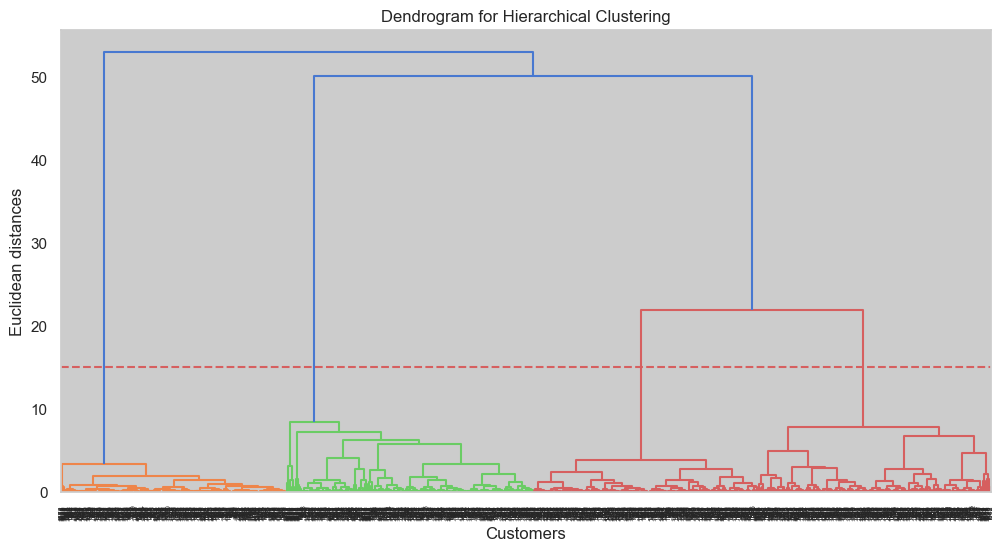

In [20]:
# Plotting the Dendrogram to visualize the hierarchical structure.
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.axhline(y=15, color='r', linestyle='--') # Theoretical cut line
plt.show()

In [22]:
# Fit Agglomerative Clustering
start_time = time.time()
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
hc_time = time.time() - start_time

# DBSCAN & K-Distance Graph

In [23]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

In [24]:
# Sort distances
distances = np.sort(distances[:, 4], axis=0)

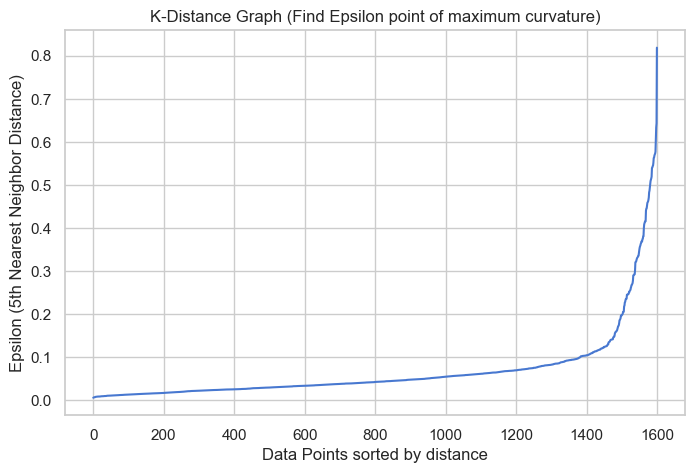

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph (Find Epsilon point of maximum curvature)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (5th Nearest Neighbor Distance)')
plt.grid(True)
plt.show()

In [26]:
# Fit DBSCAN (Using eps=0.25 based on the standard scaler graph curvature)
start_time = time.time()
dbscan = DBSCAN(eps=0.25, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_time = time.time() - start_time

# Visual Comparison of the 3 Algorithms

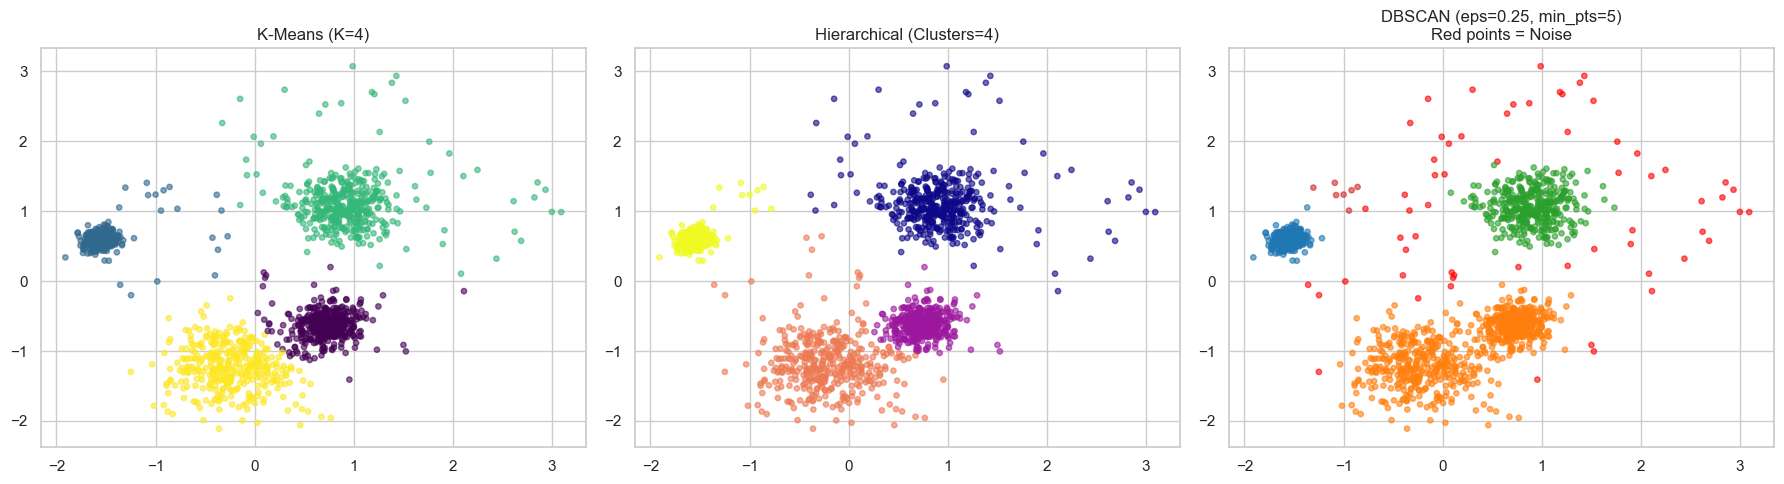

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means Plot
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=15, alpha=0.6)
axes[0].set_title('K-Means (K=4)')

# Hierarchical Plot
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap='plasma', s=15, alpha=0.6)
axes[1].set_title('Hierarchical (Clusters=4)')

# DBSCAN Plot (Noise points are -1, mapping them to red for visibility)
colors = ['red' if label == -1 else plt.cm.tab10(label % 10) for label in dbscan_labels]
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=15, alpha=0.6)
axes[2].set_title('DBSCAN (eps=0.25, min_pts=5)\nRed points = Noise')

plt.tight_layout()
plt.show()

# Comprehensive Performance Matrix

In [28]:
# Calculate industry-standard metrics to objectively compare performance.
def evaluate_clustering(X, labels, model_name, exec_time):
    # If DBSCAN clusters everything into noise (-1), metrics will fail. 
    # We require at least 2 distinct clusters (excluding noise) for valid metrics.
    unique_labels = set(labels)
    if len(unique_labels) < 2 or (len(unique_labels) == 2 and -1 in unique_labels):
        return [model_name, np.nan, np.nan, np.nan, exec_time * 1000]
        
    sil = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    return [model_name, round(sil, 4), round(calinski, 2), round(davies, 4), round(exec_time * 1000, 2)]


In [29]:
# Compile Results
results = []
results.append(evaluate_clustering(X_scaled, kmeans_labels, "K-Means", kmeans_time))
results.append(evaluate_clustering(X_scaled, hc_labels, "Hierarchical", hc_time))
results.append(evaluate_clustering(X_scaled, dbscan_labels, "DBSCAN", dbscan_time))

metrics_df = pd.DataFrame(results, columns=["Algorithm", "Silhouette Score (↑)", "Calinski-Harabasz (↑)", "Davies-Bouldin (↓)", "Latency (ms) (↓)"])

print("\n" + "="*80)
print("FINAL PERFORMANCE COMPARISON MATRIX")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)


FINAL PERFORMANCE COMPARISON MATRIX
   Algorithm  Silhouette Score (↑)  Calinski-Harabasz (↑)  Davies-Bouldin (↓)  Latency (ms) (↓)
     K-Means                0.6910                5696.24              0.4381            106.29
Hierarchical                0.6755                5262.91              0.4566             71.79
      DBSCAN                0.6356                1861.05             20.6719             24.53


# Graphical Representation of the Matrix

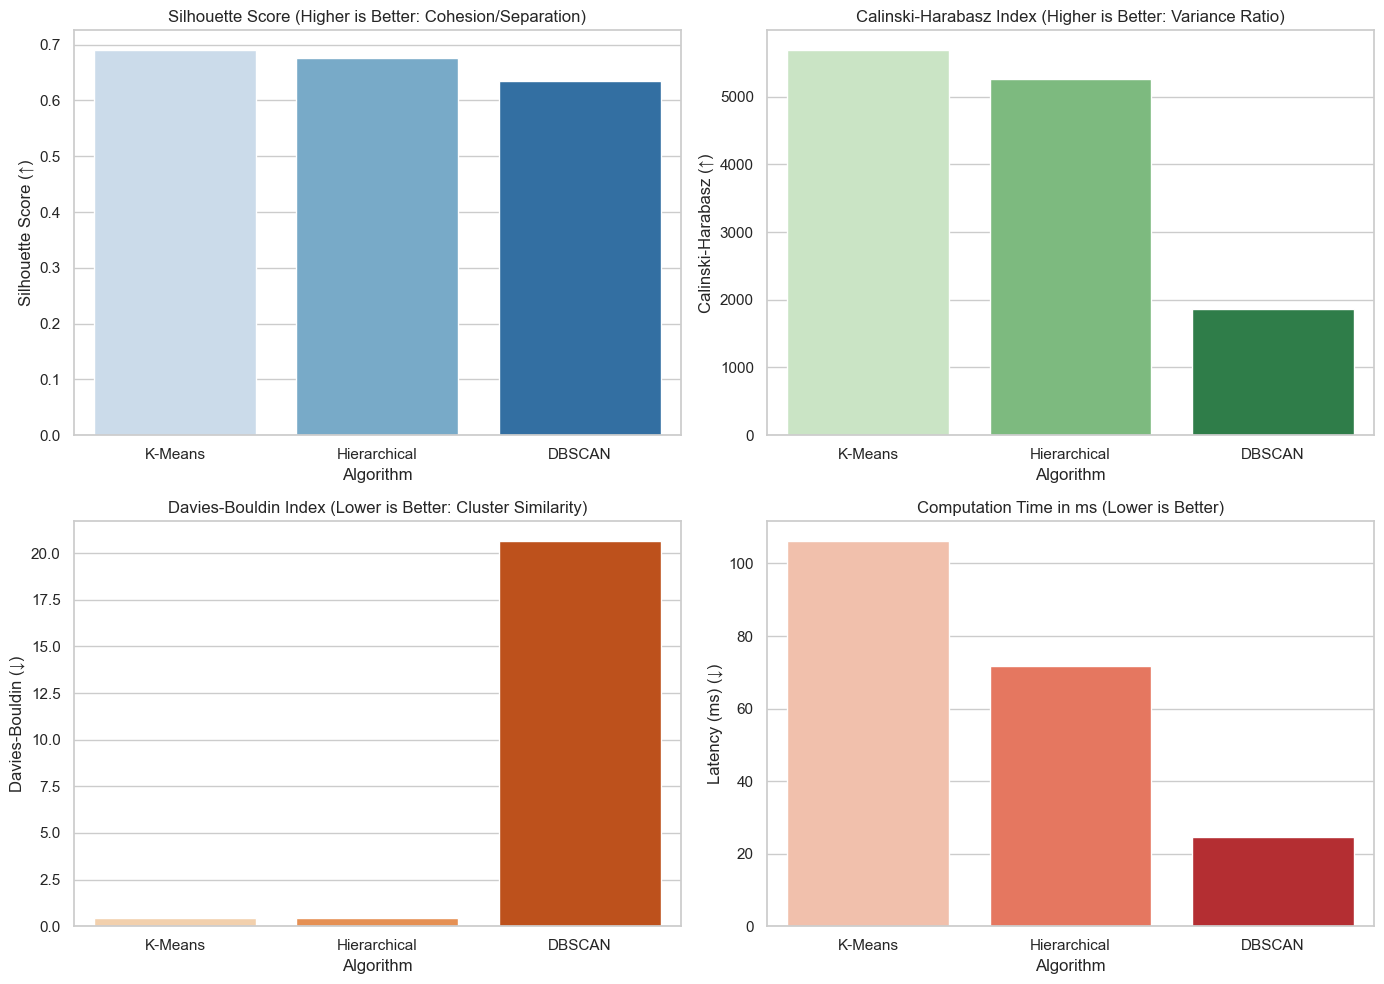

In [31]:
# Plotting the evaluation matrix for easy stakeholder consumption
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x="Algorithm", y="Silhouette Score (↑)", data=metrics_df, ax=ax[0, 0], palette="Blues")
ax[0,0].set_title("Silhouette Score (Higher is Better: Cohesion/Separation)")

sns.barplot(x="Algorithm", y="Calinski-Harabasz (↑)", data=metrics_df, ax=ax[0, 1], palette="Greens")
ax[0,1].set_title("Calinski-Harabasz Index (Higher is Better: Variance Ratio)")

sns.barplot(x="Algorithm", y="Davies-Bouldin (↓)", data=metrics_df, ax=ax[1, 0], palette="Oranges")
ax[1,0].set_title("Davies-Bouldin Index (Lower is Better: Cluster Similarity)")

sns.barplot(x="Algorithm", y="Latency (ms) (↓)", data=metrics_df, ax=ax[1, 1], palette="Reds")
ax[1,1].set_title("Computation Time in ms (Lower is Better)")

plt.tight_layout()
plt.show()